In [22]:
import cvxpy as cp
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
import plots as plots

from spins_sdp import (
    ising_hamiltonian,
    magnetization_qutip,
    gibbs_state_from_spectrum,
    npa_level,
    moment_matrix_dict,
    build_sdp_variables,
    dict_to_cvxpy_matrix_from_expr,
    ising_energy_expr,
    average_magnetization,
    ising_pauli_symbolic_terms,
    build_diagonality_constraints,
    build_lambda_matrix
)

## 1. Exact Diagonalization

In [42]:
# Model parameters
N = 2
J = 1.0
h = 0
k = 0
boundary = "periodic"
beta = 1.0
axis = 'z'

# create hamiltonian
H = ising_hamiltonian(N, J, h, k)
eigenvalues, eigenstates = H.eigenstates()

# Ground state
E0 = eigenvalues[0]
psi0 = eigenstates[0]

## 2. SDP Relaxation (Ground State Energy)

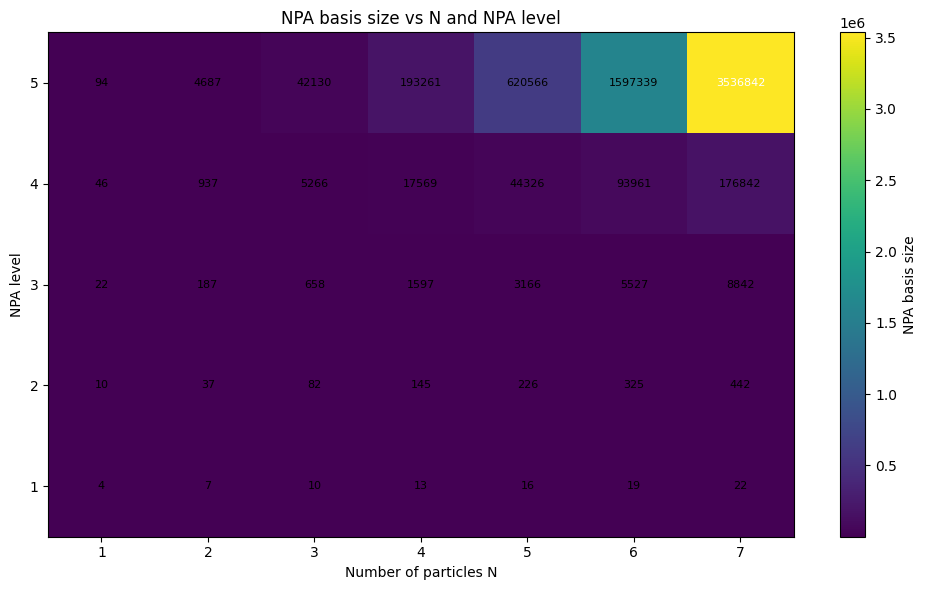

In [29]:
plots.npa_basis_size_heatmap(N=7, max_NPA_level=5)


In [44]:
# SDP parameters
NPA_level = 1
N = 2
solver = "SCS" # Look into this later

# 1. Generate basis
relaxation = npa_level(N=N, NPA_level=NPA_level)

print(relaxation)
print(f"Basis size: {len(relaxation)}")

# 2. Build Moment Matrix Dictionary
M_dict = moment_matrix_dict(relaxation)
all_labels = sorted({label for (_, label) in M_dict.values()})
print(f"Moment matrix size: {len(M_dict)}")
print(f"All labels size: {len(all_labels)}")

# Print M_dict as a matrix with headers
n = len(relaxation)
mat = [['' for _ in range(n)] for _ in range(n)]

for (i, j), (coeff, label) in M_dict.items():
  coeff = complex(coeff)
  if abs(coeff - 1) < 1e-12:
    s = label
  elif abs(coeff) < 1e-12:
    s = '0'
  else:
    s = f"({coeff})*{label}"
  mat[i][j] = s

# fill empties with '0'
for i in range(n):
  for j in range(n):
    if mat[i][j] == '':
      mat[i][j] = '0'

# print header row
print('\t' + '\t'.join(relaxation))
for i, row in enumerate(mat):
  print(relaxation[i] + '\t' + '\t'.join(row))

['I', 'x0', 'y0', 'z0', 'x1', 'y1', 'z1']
Basis size: 7
Moment matrix size: 49
All labels size: 16
	I	x0	y0	z0	x1	y1	z1
I	I	x0	y0	z0	x1	y1	z1
x0	x0	I	(1j)*z0	(-1j)*y0	x0x1	x0y1	x0z1
y0	y0	(-1j)*z0	I	(1j)*x0	y0x1	y0y1	y0z1
z0	z0	(1j)*y0	(-1j)*x0	I	z0x1	z0y1	z0z1
x1	x1	x0x1	y0x1	z0x1	I	(1j)*z1	(-1j)*y1
y1	y1	x0y1	y0y1	z0y1	(-1j)*z1	I	(1j)*x1
z1	z1	x0z1	y0z1	z0z1	(1j)*y1	(-1j)*x1	I
